### Transformer Demo (1 sample pair, 1 update) , (N=1, d_model = 4, h = 2, d_ff = 8)

In [43]:
import math
import torch
import torch.nn as nn
from transformers import AutoTokenizer

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available else "cpu"
print(f"Using {device} device")



# device = torch.device(
#     "cuda" if torch.cuda.is_available()
#     else "cpu"
# )

# print(f"Using {device} device")




Using mps device


In [44]:
d_model = 4
h = 2
N = 1
d_ff = 8
dropout_p = 0.1
max_length = 128

tokenizer  = AutoTokenizer.from_pretrained(
    "google-bert/bert-base-multilingual-cased"
)

tokenizer.add_special_tokens({
    "bos_token" : "<BOS>",
    "eos_token" : "<EOS>"
})

vocab_size = 16
# vocab_size = len(tokenizer)


In [69]:

source_text = "I'm the best boxer."
target_text = "나는 최고의 복서다."

source_token_ids = tokenizer.encode(
    source_text,
    add_special_tokens = False
)

target_token_ids = tokenizer.encode(
    target_text,
    add_special_tokens = False
)

source_input_ids = [
    *source_token_ids,
    tokenizer.eos_token_id
]

decoder_input_ids =[
    tokenizer.bos_token_id,
    *target_token_ids
]



# labels = [
#     *target_token_ids,
#     tokenizer.eos_token_id
# ]


source_input_ids = torch.tensor(
    [source_input_ids],
    dtype = torch.long,
    device = device
)

decoder_input_ids = torch.tensor(
    [decoder_input_ids],
    dtype = torch.long,
    device = device
)

# labels = torch.tensor(
#     [labels],
#     dtype = torch.long,
#     device = device
# )


labels = torch.tensor(        
    [[10, 11, 12, 13, 14, 15, 9, 2]],     
    dtype=torch.long,
    device=device,
)


print(
    "Encoder tokens:",
    tokenizer.convert_ids_to_tokens(
        source_input_ids[0].tolist()
    )
)

print(
    "Decoder input tokens:",
    tokenizer.convert_ids_to_tokens(
        decoder_input_ids[0].tolist()
    )
)

# print(
#     "Labels:",
#     tokenizer.convert_ids_to_tokens(
#         labels[0].tolist()
#     )


Encoder tokens: ['I', "'", 'm', 'the', 'best', 'boxer', '.', '<EOS>']
Decoder input tokens: ['<BOS>', '나는', '최고', '##의', '복', '##서', '##다', '.']


In [62]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(
        self,
        d_model,
        max_length=128,
        dropout_p=0.1
    ):
        super().__init__()

        self.dropout = nn.Dropout(dropout_p)

        position = torch.arange(
            max_length,
            dtype=torch.float32
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32
            )
            * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(
            1,
            max_length,
            d_model
        )

        pe[0, :, 0::2] = torch.sin(
            position * div_term
        )

        odd_size = pe[0, :, 1::2].shape[-1]

        pe[0, :, 1::2] = torch.cos(
            position * div_term[:odd_size]
        )

        self.register_buffer("pe", pe)

    def forward(self, x):
        token_len = x.size(1)

        pe = self.pe[:, :token_len].to(
            dtype=x.dtype
        )

        return self.dropout(x + pe)

In [71]:
import math
import torch
import torch.nn as nn


class TranslationTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_token_id,
        d_model=10,
        h=2,
        N=1,
        d_ff=40,
        dropout_p=0.1,
        max_length=128
    ):
        super().__init__()


        self.d_model = d_model
        self.pad_token_id = pad_token_id

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_model,
            padding_idx=pad_token_id
        )

      
        self.positional_encoding = (
            SinusoidalPositionalEncoding(
                d_model=d_model,
                max_length=max_length,
                dropout_p=dropout_p
            )
        )

        

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=h,
            dim_feedforward=d_ff,
            dropout=dropout_p,
            activation="relu",
            batch_first=True,
            norm_first=False
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=N
        )

  
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=h,
            dim_feedforward=d_ff,
            dropout=dropout_p,
            activation="relu",
            batch_first=True,
            norm_first=False
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=N
        )

        # Decoder output → vocabulary logits
        self.output_projection = nn.Linear(
            d_model,
            vocab_size,
        )

    def make_causal_mask(
        self,
        target_len,
        device
    ):
       

        return torch.triu(
            torch.ones(
                target_len,
                target_len,
                dtype=torch.bool,
                device=device
            ),
            diagonal=1
        )

    def forward(
        self,
        source_input_ids,
        decoder_input_ids
    ):
      

        source_padding_mask = (
            source_input_ids == self.pad_token_id
        )

        target_padding_mask = (
            decoder_input_ids == self.pad_token_id
        )



        source = self.embedding(
            source_input_ids
        )

        source = (
            source * math.sqrt(self.d_model)
        )

        source = self.positional_encoding(
            source
        )

      

        memory = self.encoder(
            source,
            src_key_padding_mask=source_padding_mask
        )

       
     

        target = self.embedding(
            decoder_input_ids
        )

        target = (
            target * math.sqrt(self.d_model)
        )

        target = self.positional_encoding(
            target
        )

        

        target_len = decoder_input_ids.size(1)

        causal_mask = self.make_causal_mask(
            target_len=target_len,
            device=decoder_input_ids.device
        )

       

        decoder_output = self.decoder(
            tgt=target,

            memory=memory,

            tgt_mask=causal_mask,
         
            tgt_key_padding_mask=target_padding_mask,

            memory_key_padding_mask=source_padding_mask
        )

       

        logits = self.output_projection(
            decoder_output
        )

      

        return logits, memory, decoder_output, source, target

torch.Size([1, 8])

In [72]:
model = TranslationTransformer(
    vocab_size=vocab_size,
    pad_token_id=tokenizer.pad_token_id,
    d_model=d_model,
    h=h,
    N=N,
    d_ff=d_ff,
    dropout_p=dropout_p,
    max_length=max_length
).to(device)

logits, encoder_output, decoder_output, source, target = model(
    source_input_ids,
    decoder_input_ids
)

print("Encoder output:", encoder_output.shape)
print("Decoder output:", decoder_output.shape)
print("Logits:", logits.shape)
print("Labels:", labels.shape)

Encoder output: torch.Size([1, 8, 4])
Decoder output: torch.Size([1, 8, 4])
Logits: torch.Size([1, 8, 16])
Labels: torch.Size([1, 8])


In [73]:
Z = logits
Memory = encoder_output
H = decoder_output


print("source(encoder_input): \n")
print(source,'\n')

print("targeet(decoder_input): \n")
print(target,'\n')

print("Z\n")
print(Z,'\n')
print("Memory\n")
print(Memory,'\n')
print("H\n")
print(H,'\n')




source(encoder_input): 

tensor([[[ 0.0000,  1.1111,  0.0000,  1.1111],
         [ 0.9350,  0.6003,  0.0111,  1.1111],
         [ 1.0103, -0.4624,  0.0222,  1.1109],
         [ 0.1568, -1.1000,  0.0333,  1.1106],
         [-0.8409, -0.7263,  0.0444,  1.1102],
         [-1.0655,  0.0000,  0.0555,  1.1097],
         [-0.3105,  1.0669,  0.0666,  0.0000],
         [ 0.7300,  0.8377,  0.0000,  1.1084]]], device='mps:0', grad_fn=<MulBackward0>) 

targeet(decoder_input): 

tensor([[[ 0.0000,  1.1111,  0.0000,  1.1111],
         [ 0.9350,  0.6003,  0.0111,  1.1111],
         [ 1.0103, -0.4624,  0.0222,  1.1109],
         [ 0.1568, -1.1000,  0.0333,  1.1106],
         [-0.8409, -0.0000,  0.0000,  1.1102],
         [-0.0000,  0.3152,  0.0555,  1.1097],
         [-0.3105,  1.0669,  0.0666,  0.0000],
         [ 0.7300,  0.8377,  0.0777,  1.1084]]], device='mps:0', grad_fn=<MulBackward0>) 

Z

tensor([[[-0.9165, -0.3853,  0.3681,  0.7124, -0.2627,  0.0073, -1.2295, -0.7009, -0.2703,  0.7427,  0.187

In [74]:
criterion = nn.CrossEntropyLoss(
    ignore_index=tokenizer.pad_token_id,
    label_smoothing = 0.1
)

loss = criterion(
    logits.reshape(-1, logits.size(-1)),
    labels.reshape(-1)
)

print("loss:", loss.item())

loss: 2.8164148330688477


In [77]:
P = torch.softmax(Z, dim=-1)
P

tensor([[[0.0267, 0.0454, 0.0965, 0.1361, 0.0514, 0.0673, 0.0195, 0.0331, 0.0510, 0.1403, 0.0806, 0.0278, 0.0146, 0.0298, 0.0917, 0.0882],
         [0.0467, 0.0646, 0.0720, 0.1383, 0.0600, 0.0973, 0.0244, 0.0177, 0.0985, 0.0706, 0.0894, 0.0323, 0.0094, 0.0524, 0.0931, 0.0334],
         [0.1207, 0.0627, 0.0687, 0.0755, 0.0545, 0.0922, 0.0413, 0.0223, 0.0989, 0.0383, 0.0702, 0.0438, 0.0178, 0.0995, 0.0658, 0.0277],
         [0.1526, 0.0481, 0.0792, 0.0592, 0.0509, 0.0859, 0.0426, 0.0288, 0.0872, 0.0405, 0.0596, 0.0441, 0.0243, 0.1022, 0.0610, 0.0337],
         [0.0732, 0.0311, 0.1213, 0.0765, 0.0497, 0.0727, 0.0267, 0.0474, 0.0566, 0.1098, 0.0598, 0.0335, 0.0273, 0.0486, 0.0787, 0.0871],
         [0.0681, 0.0384, 0.1032, 0.0988, 0.0563, 0.0921, 0.0241, 0.0293, 0.0832, 0.0937, 0.0698, 0.0319, 0.0159, 0.0515, 0.0913, 0.0523],
         [0.0183, 0.0688, 0.0799, 0.1324, 0.0440, 0.0437, 0.0268, 0.0463, 0.0283, 0.1278, 0.0872, 0.0336, 0.0232, 0.0287, 0.0682, 0.1428],
         [0.0410, 0.0637, 0

In [ ]:

import torch.nn.functional as F

V = 16
epsilon = 0.1

# labels shape: [1, 8]
one_hot_labels = F.one_hot(
    labels,
    num_classes=V,
).to(dtype=logits.dtype)

Q = (
    (1.0 - epsilon) * one_hot_labels
    + epsilon / V
)

### Update

In [49]:
import copy
import math
import torch
import torch.nn as nn

# 원본 model을 보존하고 복사본으로 update 실험
demo_model = copy.deepcopy(model).to(device)
demo_model.train()

print("source:", source_input_ids.shape)
print("decoder input:", decoder_input_ids.shape)
print("labels:", labels.shape)

assert source_input_ids.size(0) == 1
assert decoder_input_ids.size(0) == 1
assert labels.size(0) == 1

# 계산을 확인하기 위한 고정 learning rate
demo_lr = 1e-4
beta1 = 0.9
beta2 = 0.98
adam_eps = 1e-9
weight_decay = 0.01
grad_clip = 1.0

demo_optimizer = torch.optim.AdamW(
    demo_model.parameters(),
    lr=demo_lr,
    betas=(beta1, beta2),
    eps=adam_eps,
    weight_decay=weight_decay,
    fused=False,
)

demo_optimizer.zero_grad(set_to_none=True)

source: torch.Size([1, 8])
decoder input: torch.Size([1, 8])
labels: torch.Size([1, 8])


In [50]:
forward_result = demo_model(
    source_input_ids,
    decoder_input_ids,
)

# 모델이 logits만 반환하거나 tuple을 반환하는 경우 모두 처리
if isinstance(forward_result, tuple):
    logits = forward_result[0]
else:
    logits = forward_result

print("logits shape:", logits.shape)

# [batch=1, target_len, vocab_size]
B, T, V = logits.shape

assert B == 1
assert labels.shape == (B, T)

logits shape: torch.Size([1, 8, 119549])


In [17]:
flat_logits = logits.reshape(-1, V)
flat_labels = labels.reshape(-1)

ignore_index = criterion.ignore_index
label_smoothing = getattr(
    criterion,
    "label_smoothing",
    0.0,
)

valid_mask = flat_labels.ne(ignore_index)

# ignore_index가 -100이면 gather에 사용할 수 없으므로 0으로 임시 교체
safe_labels = flat_labels.masked_fill(
    ~valid_mask,
    0,
)

log_probs = torch.log_softmax(
    flat_logits,
    dim=-1,
)

probs = torch.softmax(
    flat_logits,
    dim=-1,
)

# 정답 token의 negative log likelihood
nll = -log_probs.gather(
    dim=1,
    index=safe_labels.unsqueeze(1),
).squeeze(1)

# 전체 vocabulary에 균등하게 분배되는 smoothing loss
smooth_loss = -log_probs.mean(dim=1)

token_losses = (
    (1.0 - label_smoothing) * nll
    + label_smoothing * smooth_loss
)

manual_loss = token_losses[valid_mask].mean()

pytorch_loss = criterion(
    flat_logits,
    flat_labels,
)

print("manual loss:", manual_loss.item())
print("PyTorch loss:", pytorch_loss.item())
print(
    "difference:",
    abs(manual_loss.item() - pytorch_loss.item())
)

manual loss: 12.003235816955566
PyTorch loss: 12.00323486328125
difference: 9.5367431640625e-07


In [18]:
for position in range(T):
    target_id = labels[0, position].item()

    if target_id == ignore_index:
        continue

    predicted_id = probs[position].argmax().item()
    target_probability = probs[
        position,
        target_id,
    ].item()

    print(
        f"position={position:2d}",
        f"target={target_id:5d}",
        f"prediction={predicted_id:5d}",
        f"P(target)={target_probability:.6f}",
        f"loss={token_losses[position].item():.6f}",
    )

position= 0 target=100585 prediction=88433 P(target)=0.000002 loss=13.027626
position= 1 target=83491 prediction=72455 P(target)=0.000035 loss=10.425172
position= 2 target=10459 prediction=96791 P(target)=0.000005 loss=12.216426
position= 3 target= 9357 prediction=11848 P(target)=0.000004 loss=12.459941
position= 4 target=12424 prediction=63192 P(target)=0.000008 loss=11.698303
position= 5 target=11903 prediction=116523 P(target)=0.000003 loss=12.629399
position= 6 target=  119 prediction=42475 P(target)=0.000009 loss=11.635142
position= 7 target=119548 prediction=12026 P(target)=0.000007 loss=11.933874


In [19]:
Loss = (10.292443+12.042827
+11.826744+11.868369
+12.695313
+11.625059
+11.338011
+11.344776)

Loss/8

11.629192749999998

In [20]:
pytorch_loss.backward()

total_grad_norm = torch.nn.utils.clip_grad_norm_(
    demo_model.parameters(),
    max_norm=grad_clip,
)

print(
    "clipping 전 gradient norm:",
    total_grad_norm.item()
)

clipping 전 gradient norm: 1.497331976890564


In [21]:
# 마지막 Linear weight처럼 2차원인 마지막 parameter 선택
parameter_name, parameter = next(
    (name, param)
    for name, param in reversed(
        list(demo_model.named_parameters())
    )
    if param.requires_grad
    and param.grad is not None
    and param.ndim == 2
)

parameter_before = parameter.detach().clone()

# gradient가 가장 큰 원소를 선택
flat_index = parameter.grad.abs().argmax().item()

row = flat_index // parameter.shape[1]
col = flat_index % parameter.shape[1]

theta_0 = parameter_before[row, col].item()
gradient = parameter.grad[row, col].item()

# Adam 첫 번째 moment
m_1 = (1.0 - beta1) * gradient

# Adam 두 번째 moment
v_1 = (1.0 - beta2) * gradient**2

# 첫 번째 step의 bias correction
m_hat = m_1 / (1.0 - beta1)
v_hat = v_1 / (1.0 - beta2)

adam_update = (
    m_hat
    / (math.sqrt(v_hat) + adam_eps)
)

# AdamW의 예상 parameter
expected_theta_1 = (
    theta_0 * (1.0 - demo_lr * weight_decay)
    - demo_lr * adam_update
)

print("parameter:", parameter_name)
print("parameter shape:", parameter.shape)

print("선택 위치:", (row, col))
print("update 전:", theta_0)
print("gradient:", gradient)
print("m₁:", m_1)
print("v₁:", v_1)
print("m̂₁:", m_hat)
print("v̂₁:", v_hat)
print("예상 update 후:", expected_theta_1)

parameter: output_projection.weight
parameter shape: torch.Size([119549, 10])
선택 위치: (119, 8)
update 전: 0.0831187516450882
gradient: -0.1574903279542923
m₁: -0.015749032795429226
v₁: 0.0004960640679830113
m̂₁: -0.1574903279542923
v̂₁: 0.024803203399150542
예상 update 후: 0.08321866852570159


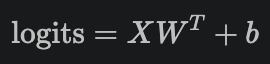

In [22]:
demo_optimizer.step()

actual_theta_1 = parameter[row, col].item()

print("실제 update 후:", actual_theta_1)
print("변화량:", actual_theta_1 - theta_0)
print(
    "수동 계산과 오차:",
    abs(actual_theta_1 - expected_theta_1)
)

실제 update 후: 0.08321867138147354
변화량: 9.991973638534546e-05
수동 계산과 오차: 2.855771952248176e-09


### Calculate By Hand

In [25]:
z = forward_result[0]
memory = forward_result[1]
h = forward_result[2]

print(f"z shape : {z.shape}")
print(f"memory shape : {memory.shape}")
print(f"h shape : {h.shape}")


z shape : torch.Size([1, 8, 119549])
memory shape : torch.Size([1, 8, 10])
h shape : torch.Size([1, 8, 10])


In [26]:
d_model

10